In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader

import pytorch_lightning as pl

from torchmetrics.classification import BinaryAUROC

from datetime import datetime

from tqdm.notebook import tqdm

In [2]:
# Build Dataset
def build_task_targets():
    bin_rep1 = np.arange(8) % 2
    bin_rep2 = (np.arange(8) //2) % 2
    bin_rep3 = (np.arange(8) // 4) % 2
    
    y_t1 = np.logical_xor(bin_rep1, bin_rep2).astype(int)
    y_t2 = np.logical_xor(bin_rep1, bin_rep3).astype(int)
    y_t3 = np.logical_xor(bin_rep2, bin_rep3).astype(int)
    
    y = np.stack([y_t1, y_t2, y_t3]).T
    
    df = pd.DataFrame(
        dict(
            x1 = bin_rep1,
            x2 = bin_rep2,
            x3 = bin_rep3,
            x1_xor_x2 = y_t1,
            x1_xor_x3 = y_t2,
            x2_xor_x3 = y_t3
        )
    )
    return df, y

df, arr_task_targets = build_task_targets()
df

,x1,x2,x3,x1_xor_x2,x1_xor_x3,x2_xor_x3
0,0,0,0,0,0,0
1,1,0,0,1,1,0
2,0,1,0,1,0,1
3,1,1,0,0,1,1
4,0,0,1,0,1,1
5,1,0,1,1,0,1
6,0,1,1,1,1,0
7,1,1,1,0,0,0


In [3]:
def generate_dataset(num_per_groups=200, seed=1):
    rng = np.random.default_rng(seed=1)
    
    df, arr_task_targets = build_task_targets()
    
    arr_xs = []
    arr_ys = []
    
    arr_centers = 2*df[["x1", "x2", "x3"]].values - 1
    
    assert arr_centers.shape[0] == 8
    
    for cix in range(8):
        center = arr_centers[cix]
        group_x =  rng.normal(scale=0.5, size=(num_per_groups, 3)) + center
        arr_xs.append(group_x)
        
        
        code = np.array(list(np.binary_repr(2, width=3))).astype(int)
    
        ys = np.tile(arr_task_targets[cix], num_per_groups).reshape((num_per_groups, 3))
        arr_ys.append(ys)
        
    X = np.vstack(arr_xs)
    y = np.vstack(arr_ys)
    
    assert X.shape[0] == y.shape[0] == num_per_groups * 8 
    
    num_datapoints = num_per_groups * 8 
    
    return train_test_split(X, y, test_size=0.5, random_state=seed)

X_train, X_test, y_train, y_test = generate_dataset() 

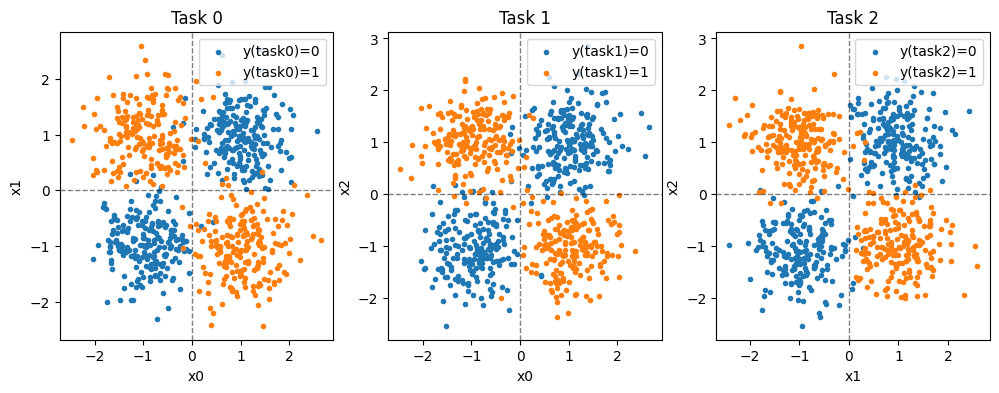

In [4]:
def viz(X, y):
    
    plt.figure(figsize=(3*4, 4))
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    for tidx in range(3):
        plt.subplot(1, 3, tidx + 1)
        plt.title(f"Task {tidx}")
        
        coord1, coord2 = arr_coords[tidx]
        for ans in [0, 1]:

            selected = y[:, tidx] == ans

            plt.scatter(
                X[selected, coord1], X[selected, coord2],
                marker=".",
                label=f"y(task{tidx})={ans}"
            )
        plt.axhline(0, ls="--", lw=1, color="k", alpha=0.5)
        plt.axvline(0, ls="--", lw=1, color="k", alpha=0.5)
        plt.legend()
        plt.xlabel(f"x{coord1}")
        plt.ylabel(f"x{coord2}")
        
viz(X_train, y_train)

# Construct Model and Train

In [54]:
class MLP(nn.Module):
    def __init__(self, num_tasks=3):
        super().__init__()
        
        d = 128
        # d = 2
        
        self.lin1 = nn.Linear(3, d)
        self.act1 = nn.ReLU()
        self.lin2 = nn.Linear(d, num_tasks, bias=False)
    def forward(self, x):
        x = self.act1(self.lin1(x))
        x = self.lin2(x)
        
        out = [
            x[:, 0],
            x[:, 1],
            x[:, 2],
        ]
        
        return out
    def __str__(self):
        d, _ = self.lin1.weight.shape
        return f"MLP(d={d})"
def ano():
    
    out = MLP()(torch.randn(10, 3))
    
    print(f"santity check: {MLP()} callable")
ano()

santity check: MLP(d=128) callable


In [55]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.SGD(
            self.parameters(), lr=self.lr, momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(3):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += (1/3)*F.binary_cross_entropy_with_logits(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()


In [56]:
pl.seed_everything(1)

dl_train = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).float()
    ),
    batch_size=64,
    shuffle=True,
)

dl_train_noshuffle = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).float()
    ),
    batch_size=64,
    shuffle=False,
)

dl_test = DataLoader(
    TensorDataset(
        torch.from_numpy(X_test).float(),
        torch.from_numpy(y_test).float()
    ),
    batch_size=64,
    shuffle=True,
)

model  = MLP()

trainer = pl.Trainer(
    max_epochs=500,
    default_root_dir="/tmp"
)

trainer.fit(ModelWrapper(model), dl_train, dl_test)

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type | Params
---------------------------------
0 | encoder | MLP  | 896   
--------------------------

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


In [57]:
def estimate_task_auroc(model, dl, task_id):
    metric_auroc = BinaryAUROC()

    for x, y in dl:
        task_logit = model(x)[task_id]
        task_target = y[:, task_id]
        metric_auroc.update(task_logit, task_target)

    auroc = float(metric_auroc.compute())
    auroc = 1-auroc if auroc < 0.5 else auroc
    return auroc

def compute_aurocs():
    
    stats = dict()
    
    for tidx in range(3):
        
        for label, dl in [
            ("train", dl_train),
            ("test", dl_test)
        ]:            
            stats[f"auroc_task_{tidx}_{label}"] = estimate_task_auroc(model, dl, tidx)
    
    return stats

ref_stats = compute_aurocs()
ref_stats

{'auroc_task_0_train': 0.9920439720153809,
 'auroc_task_0_test': 0.9897671937942505,
 'auroc_task_1_train': 0.9867480397224426,
 'auroc_task_1_test': 0.9769731163978577,
 'auroc_task_2_train': 0.9896681904792786,
 'auroc_task_2_test': 0.9840741157531738}

In [58]:

def grad_hook(mod, inp, outp):
    outp.retain_grad()
    setattr(mod, "__outp", outp)

def extract_act_grad(model, dl, task_id):
    module_name = "act1"
    arr_act = []
    arr_ctx = []
    module = getattr(model, module_name)
    for x, y in dl:
                
        try:

            x.requires_grad_()
            hook = module.register_forward_hook(grad_hook)

            arr_logits = model(x)
            task_logit = arr_logits[task_id]
            task_logit.sum().backward()
        
            act = getattr(module, "__outp")
            ctx = act.grad.detach().numpy()
            act = act.detach().numpy()
            arr_act.append(act)
            arr_ctx.append(ctx)
            
            
        finally:
            hook.remove()
    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
    
    return arr_act, arr_ctx

extract_act_grad(model, dl_train_noshuffle, 0)

(array([[0.        , 0.3632201 , 0.        , ..., 0.        , 0.        ,
         0.0797367 ],
        [0.        , 0.        , 0.5920345 , ..., 0.        , 0.        ,
         0.86653423],
        [0.24300379, 1.8436761 , 0.        , ..., 0.8228952 , 0.        ,
         0.        ],
        ...,
        [0.        , 1.4706812 , 0.05837281, ..., 0.8762611 , 0.        ,
         0.        ],
        [0.43848675, 0.8948729 , 0.        , ..., 0.        , 0.00960082,
         0.        ],
        [0.        , 1.4806073 , 0.        , ..., 0.78729194, 0.        ,
         0.        ]], dtype=float32),
 array([[-0.02220923,  0.1344543 ,  0.07696348, ..., -0.02676396,
         -0.09538123,  0.07667474],
        [-0.02220923,  0.1344543 ,  0.07696348, ..., -0.02676396,
         -0.09538123,  0.07667474],
        [-0.02220923,  0.1344543 ,  0.07696348, ..., -0.02676396,
         -0.09538123,  0.07667474],
        ...,
        [-0.02220923,  0.1344543 ,  0.07696348, ..., -0.02676396,
         

In [59]:
def sanity_check():
    arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1, 2]:
        arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")
sanity_check()

arr_act(T0) == arr_act(T1)
arr_act(T0) == arr_act(T2)
all passed!


# Basis Comparision

In [180]:
import torch

import numpy as np
import numpy.typing as npt


from tqdm.autonotebook import tqdm


def atol(mode):
    if mode == "reconnaive":
        return 1e-2
    else:
        return 1e-5


def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs

def estimate_basis(basis_name, arr_act, arr_ctx):
    if basis_name == "pca":
        cov = arr_act.T @ arr_act
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    if basis_name == "gpca":
        cov = arr_ctx.T @ arr_ctx
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    elif basis_name == "prca-sortabs":
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        eigvecs = _solve_eigvecs(cov, sort_func=np.abs)
        return eigvecs
    elif basis_name == "prca-signed":
        arr_rel = (arr_act * arr_ctx).sum(axis=1, keepdims=True)
        arr_ctx_signed = (arr_rel >= 0) * arr_ctx - (arr_rel < 0) * arr_ctx
        return estimate_basis("prca-sortabs", arr_act, arr_ctx_signed)
    elif basis_name == "prca-recon":
        learner = PRCAGreedyLeaner(mode="recon")
        return learner.fit(activation=arr_act, context=arr_ctx)
    elif basis_name == "prca-recon-idv":
        learner = PRCAGreedyLeaner(mode="recon-idv")
        arr_rel = (arr_act * arr_ctx).sum(axis=1, keepdims=True)
        arr_ctx = (arr_rel >= 0) * arr_ctx - (arr_rel < 0) * arr_ctx
        return learner.fit(
            activation=arr_act,
            context=arr_ctx,
        )
    else:
        raise


class PRCAGreedyLeaner:
    def __init__(self, mode: str) -> None:
        if mode == "abs":
            self.obj_func = PRCAGreedyLeaner._obj_abs
        elif mode == "recon":
            self.obj_func = PRCAGreedyLeaner._obj_recon
        elif mode == "recon-idv":
            self.obj_func = PRCAGreedyLeaner._obj_recon_idv
        elif mode == "reconnaive":
            self.obj_func = PRCAGreedyLeaner._obj_recon_naive
        else:
            raise ValueError(f"No mode=`{mode}` available!")

        self.mode = mode

    def fit(
        self,
        activation: npt.NDArray,
        context: npt.NDArray,
        epochs=200,
        seed=1,
        eps=1e-16,  # todo: this parameter seem to be very important!
        device="cpu",
        beta=0.0,
    ) -> npt.NDArray:
        assert activation.shape == context.shape

        _, d = activation.shape

        Uprca_signed = estimate_basis("prca-signed", activation, context)
        
        activation = activation / ((np.mean(activation**2) ** (1 / 2)) * (d ** (1 / 4)))
        context = context / ((np.mean(context**2) ** (1 / 2)) * (d ** (1 / 4)))

        activation = torch.from_numpy(activation).float().to(device)
        context = torch.from_numpy(context).float().to(device)

        rng = torch.Generator()
        rng.manual_seed(seed)

        U = torch.zeros(d, d)
        U = U.to(device)

        I = torch.eye(d).to(device)

        R = (activation * context).sum(dim=1)

        largest_d = 3
        for k in tqdm(
            range(largest_d), 
            total=largest_d, desc=f"[mode={self.mode},beta={beta},device={device}]"
        ):
            U_complement = I - U @ U.T

            # take the kth vector of Uprca_sign
            # v = Uprca_signed[:, k]
            # take a random vector
            v = torch.randn(d, generator=rng).to(device)

            v = U_complement @ v

            v = v / torch.linalg.norm(v)
            v = v.to(device)

            for _ in range(epochs):
                v.requires_grad_(True)
                v.grad = None

                obj = self.obj_func(activation, context, U_complement, v, beta)

                obj.backward()

                with torch.no_grad():
                    ov = v

                 
                    # lr = 1e-2
                    # lr = 1
                    grad = v.grad
                    grad = (I -  torch.outer(v, v)) @ grad
                    # grad = grad / (torch.linalg.norm(grad) + 1e-16) * 2.7795496
                    # g = gra
                    # nom = R - (activation @ v) * (context @ v)
                    # denom =  (activation @ v) * (context @ g) +  (activation @ g) * (context @ v) +  (activation @ g) * (context @ g)

                    # alpha = (nom / denom).mean()
                    # if k <= 5:
                    #     print(f"[k={k}]: E{_}: {alpha:.4e}")
                    # lr = alpha

                    def exponential_map(p, g, t):
                        norm_g = torch.linalg.norm(g)
                        return torch.cos(norm_g * t)*p + torch.sin(norm_g * t) * (g / (norm_g + 1e-16))

                    # line search

                    def linesearch(u, g):
                        
                        arr_stats = []
                        arr_ticks = np.linspace(0, np.pi, 100).tolist()
                        for alpha in arr_ticks:
                            arr_stats.append(
                                self.obj_func(
                                    activation, context, U_complement, 
                                    exponential_map(
                                        u, g, alpha
                                    ), 
                                    0.0
                                ).detach().numpy()
                            )
                        best_ix = np.argmax(arr_stats)
                        best_lr = arr_ticks[best_ix]

                        return best_lr
                        
                    lr = linesearch(v, grad)
                    if k == 0:  
                        print(f"[k=0]: iter {_} best lr={lr:.4e}")
                
                    # update v with gradient `ascent`.
                    # todo: can we use geodesic gradient on sphere?
                    # v = v + lr * grad
                    v = exponential_map(v, grad, lr)
                    
                    v = U_complement @ v
                    v = v / torch.linalg.norm(v)

                    if (v @ ov).abs() > (1 - eps):
                        pass
                        # stop if the solution isn't update anymore.
                        break
            if k < 5:
                print(f"[k={k}] obj={obj:.4e} (norm(grad)={torch.linalg.norm(grad).detach().cpu().numpy():.4e})")

            # testing orthogonality
            np.testing.assert_allclose(
                (U.T @ v).detach().cpu().numpy(),
                np.zeros(U.shape[1]),
                atol=atol(self.mode),
            )

            U[:, k] = v.detach()

        # np.testing.assert_allclose(
        #     (U.T @ U).detach().cpu().numpy(), np.eye(d), atol=atol(self.mode)
        # )

        return U.detach().cpu().numpy()

    @staticmethod
    def _obj_abs(
        activation: torch.Tensor,
        context: torch.Tensor,
        U_complement: torch.Tensor,
        u: torch.Tensor,
        beta=0,
    ) -> torch.Tensor:
        assert beta == 0, f"setting beta={beta} has not effect here."

        activation = activation @ U_complement
        context = context @ U_complement

        activation_projected = activation.matmul(u)
        context_projected = context.matmul(u)

        assert len(activation_projected.shape) == len(context_projected.shape) == 1

        obj = (activation_projected * context_projected).abs()
        assert len(obj.shape) == 1 and obj.shape[0] == activation.shape[0]
        return obj.mean()

    @staticmethod
    def _obj_recon(
        activation: torch.Tensor,
        context: torch.Tensor,
        IUUt: torch.Tensor,
        u: torch.Tensor,
        beta=0,
    ) -> torch.Tensor:
        activation = activation @ IUUt
        context = context @ IUUt

        activation_projected = activation.matmul(u)
        context_projected = context.matmul(u)

        assert len(activation_projected.shape) == len(context_projected.shape) == 1

        relevance_original = (activation * context).sum(dim=1)
        relevance_projected = activation_projected * context_projected
        assert relevance_original.shape == relevance_projected.shape

        obj = (relevance_original - relevance_projected) ** 2

        assert len(obj.shape) == 1 and obj.shape[0] == activation.shape[0]

        # convert the problem into maximization problem.
        loss = -obj.mean()

        # reg = (beta * torch.abs(activation_projected)).mean()

        return loss
        # + reg

    @staticmethod
    def _obj_recon_idv(
        activation: torch.Tensor,
        context: torch.Tensor,
        IUUt: torch.Tensor,
        u: torch.Tensor,
        beta=0,
    ) -> torch.Tensor:
        activation = activation @ IUUt
        context = context @ IUUt

        uuT = u.outer(u)

        activation_projected = activation @ uuT
        context_projected = context @ uuT

        assert len(activation_projected.shape) == len(context_projected.shape) == 2

        assert activation.shape == activation_projected.shape

        relevance_original = activation * context
        relevance_projected = activation_projected * context_projected
        assert relevance_original.shape == relevance_projected.shape

        obj = (relevance_original - relevance_projected) ** 2

        assert len(obj.shape) == 2 and obj.shape == activation.shape

        # convert the problem into maximization problem.
        loss = -obj.mean()

        return loss
        
        
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return outp @ (Uk@Uk.T)
    return fh

def compute_task_auroc_at_k(
    model, task_id, arr_ks,
    arr_basis_names=["pca", "prca-sortabs", "prca-signed", "prca-signed-norm", "gpca"]
):
    arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    arr_stat_rows = []
    
    module = getattr(model, "act1")
    
    for basis_name in arr_basis_names:
        U = estimate_basis(basis_name, arr_act, arr_ctx)
        for k in arr_ks:
            Uk = torch.from_numpy(U[:, :k])
            row = dict(
                task_id=task_id, 
                basis_name=basis_name,
                k=k,   
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("train", dl_train_noshuffle),
                    ("test", dl_test)
                ]:
                    row[f"auroc_{label}"] = estimate_task_auroc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
    df = pd.DataFrame(arr_stat_rows)
    
    return df

compute_task_auroc_at_k(
    model, 
    task_id=0, 
    arr_ks=np.arange(1, 3).tolist() + [64],
    arr_basis_names=[
        # "prca-recon",
        "pca",
        "prca-signed",
        "prca-recon",
        # "prca-recon-idv",
        "gpca"
    ]
)

[mode=recon,beta=0.0,device=cpu]:   0%|          | 0/3 [00:00<?, ?it/s]

[k=0]: iter 0 best lr=1.0472e+00
[k=0]: iter 1 best lr=5.7120e-01
[k=0]: iter 2 best lr=2.4117e+00
[k=0]: iter 3 best lr=3.1099e+00
[k=0]: iter 4 best lr=6.3467e-02
[k=0]: iter 5 best lr=3.1733e-02
[k=0]: iter 6 best lr=3.1733e-02
[k=0]: iter 7 best lr=2.6973e+00
[k=0]: iter 8 best lr=2.7608e+00
[k=0]: iter 9 best lr=0.0000e+00
[k=0] obj=-2.9157e-02 (norm(grad)=7.3406e-01)
[k=1] obj=-9.6151e-04 (norm(grad)=6.7341e-03)
[k=2] obj=-9.5789e-04 (norm(grad)=1.3400e-05)


,task_id,basis_name,k,auroc_train,auroc_test
0,0,pca,1,0.533009,0.513854
1,0,pca,2,0.511793,0.545256
2,0,pca,64,0.992038,0.989849
3,0,prca-signed,1,0.954572,0.965055
4,0,prca-signed,2,0.992044,0.989767
5,0,prca-signed,64,0.992044,0.989767
6,0,prca-recon,1,0.991231,0.989223
7,0,prca-recon,2,0.991900,0.989736
8,0,prca-recon,64,0.991888,0.989755
9,0,gpca,1,0.992044,0.989767


In [179]:
def viz_rel_scatter():
    arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id=0)
    rel = (arr_act * arr_ctx).sum(axis=1)

    # Uprca_signed = estimate_basis("prca-signed", arr_act, arr_ctx)
    # u1_prca_signed = Uprca_signed[:, 0]
    
    # plt.figure(figsize=(3, 3))
    # plt.axhline(0, ls=":", color="k")
    # plt.axvline(0, ls=":", color="k")

    # rel_on_gpca = (arr_act @ u1_gpca) * (arr_ctx @ u1_gpca)
    # rel_on_prca_signed = (arr_act @ u1_prca_signed) * (arr_ctx @ u1_prca_signed)
    # plt.scatter(
    #     rel_on_gpca,
    #     rel_on_prca_signed,
    #     marker="."
    # )
    # for label in [0, 1]:
    #     selected = np.argwhere(y_train == label).reshape(-1)
    #     plt.scatter(
    #         arr_act[selected, 0],
    #         arr_act[selected, 1],
    #         marker=".",
    #         color="blue" if label == 0 else "red",
    #         alpha=0.05
        # )
    
    # plt.scatter(
    #     [Ugpca[0, 0]],
    #     [Ugpca[1, 0]],
    #     marker="x",
    #     label="w"
    # )
    # arr_ks = np.arange(10)
    for basis_name in ["gpca", "prca-signed", "prca-recon"]:
        U = estimate_basis(basis_name, arr_act, arr_ctx)

        rel_on_u = (arr_act @ U[:, 0]) * (arr_ctx @ U[:, 0])
        diff = (rel - rel_on_u)**2
        print(f"[basis_name={basis_name}]: {diff.mean():.4f}")
    # plt.legend()
    
viz_rel_scatter()

[basis_name=gpca]: 0.0000
[basis_name=prca-signed]: 0.2190


[mode=recon,beta=0.0,device=cpu]:   0%|          | 0/3 [00:00<?, ?it/s]

[k=0]: iter 0 best lr=2.5069e+00
[k=0]: iter 1 best lr=9.5200e-01
[k=0]: iter 2 best lr=2.8877e+00
[k=0]: iter 3 best lr=2.0309e+00
[k=0]: iter 4 best lr=0.0000e+00
[k=0] obj=-4.8629e-02 (norm(grad)=7.6341e-01)
[k=1] obj=-4.6392e-02 (norm(grad)=3.8070e-03)
[k=2] obj=-4.8874e-05 (norm(grad)=1.2328e-03)
[basis_name=prca-recon]: 0.0094


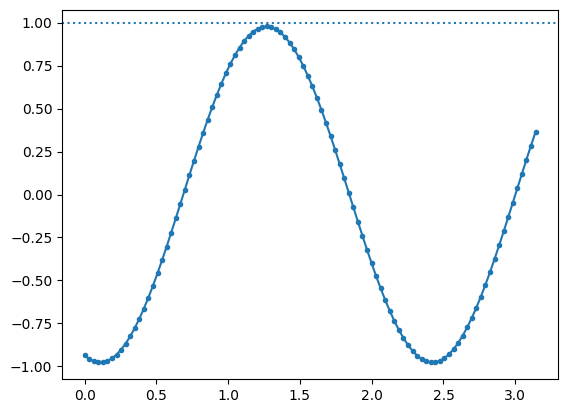

In [175]:
def ano():
    
    def exponential_map(p, g, t):
        norm_g = torch.linalg.norm(g)
        return torch.cos(norm_g * t)*p + torch.sin(norm_g * t) * (g / (norm_g + 1e-16))
        
    arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id=0)
    u_1 = estimate_basis("gpca", arr_act, arr_ctx)[:, 0]
    u_2 = estimate_basis("prca-signed", arr_act, arr_ctx)[:, 0]
    dist = np.arccos(np.dot(u_1, u_2))

    a = torch.from_numpy(arr_act)
    _, d = a.shape
    c = torch.from_numpy(arr_ctx)

    u = torch.from_numpy(u_2)
    u.requires_grad_(True)
    a_p = (a @ u)
    c_p = (c @ u)


    rel = (a*c).sum(axis=1)
    rel_proj = a_p * c_p
    
    obj = ((rel - rel_proj) ** 2).mean()
    obj.backward()

    g = u.grad

    tangent = (torch.eye(d) - torch.outer(u, u)) * g

    arr_stats = []
    arr_ticks = np.linspace(0, np.pi, 100).tolist()
    for alpha in arr_ticks:
        arr_stats.append(
            exponential_map(
                u, g, alpha
            ).detach().numpy().dot(u_1)
        )
    plt.plot(arr_ticks, arr_stats, marker=".")
    plt.axhline(1, ls=":")
        

ano()

In [172]:
np.pi

3.141592653589793

In [12]:
raise

RuntimeError: No active exception to reraise

# Accuracy Curves

In [ ]:
def viz(arr_basis_names=["pca", "gpca", "prca-sortabs"], max_k=10):
    
    arr_task_ids = np.arange(3)
    plt.figure(figsize=(3*3, 2))
    
    d = model.lin1.weight.shape[0]

    arr_ks = np.linspace(0, max_k).astype(int).tolist() + [d]
    
    plt.suptitle(model, y=1.1)
    
    for task_id in tqdm(arr_task_ids):
        plt.subplot(1, 3, task_id+1)
        
        df = compute_task_auroc_at_k(model, task_id=task_id, arr_ks=arr_ks)
        
        for basis_name in arr_basis_names:
            _df = df[
                (df.basis_name == basis_name) & (df.k <= max_k)
            ]
            
            if basis_name == "pca":
                
                ref = _df.auroc_train.values[-1]
                plt.title(f"Task {task_id} (auroc={ref:.4f})")

                plt.axhline(
                    ref,
                    ls="-",
                    lw=1,
                    color="k",
                    label="model:train"
                )
            
            for label in ["train", "test"]:

        
                
                
                if label == "test":
                    color = plt.gca().lines[-1].get_color()
                    ls = "--"
                else:
                    color = None
                    ls = "-"
        
                plt.plot(
                    _df.k,
                    _df[f"auroc_{label}"],
                    color=color,
                    ls=ls,
                    label=f"{basis_name}:{label}"
                )
        plt.ylim([0.5, 1.0])
        if task_id == 0:
            plt.legend()
            plt.ylabel("AUROC")
        plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
viz()

In [ ]:
viz(arr_basis_names=["prca-sortabs", "prca-signed"])

# Decision Boundary

In [ ]:
ref_stats

In [ ]:
def decision_boundary(task_id, arr_ks=[1, 2, 3, 4, 5]):

    arr_basis_names = ["pca", "prca-sortabs", "prca-signed", "gpca",]
    
    d = model.lin1.weight.shape[0]
    arr_ks = arr_ks + [d]
    
    nrows = len(arr_basis_names)
    ncols = len(arr_ks)
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    
    _xx = np.linspace(-3, 3, 20)
    module = getattr(model, "act1")
    plt.figure(figsize=(2*ncols, 2*nrows))
    
    auroc_train = ref_stats[f"auroc_task_{task_id}_train"]
    auroc_test = ref_stats[f"auroc_task_{task_id}_test"]
    plt.suptitle(
        f"Task {task_id} (auroc(train,test)={auroc_train:.4f},{auroc_test:.4f})",
        y=1.0
    )
    
    arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    
    for bix, basis_name in enumerate(arr_basis_names):
        
        U = estimate_basis(basis_name, arr_act, arr_ctx)

        coord_1, coord_2 = arr_coords[task_id]

        X = np.zeros((400, 3))
        
        xx, yy = np.meshgrid(_xx, _xx)
        
        X[:, coord_1] = xx.reshape(-1)
        X[:, coord_2] = yy.reshape(-1)
        
        X = torch.from_numpy(X).float()
        for kix, k in enumerate(arr_ks):
            Uk = torch.from_numpy(U[:, :k])
            plt.subplot(nrows, ncols, bix * ncols + kix + 1)
            if bix == 0:
                plt.title(f"k={k}/{d}")
            
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                task_logits = model(X)[task_id].detach().numpy()
                
                auroc = estimate_task_auroc(
                    model,
                    dl_test,
                    task_id=task_id
                )
            
            finally:
                hook.remove()
                     
            plt.contourf(
                X[:, coord_1].reshape((20, 20)),
                X[:, coord_2].reshape((20, 20)),
                task_logits.reshape((20, 20)),
                levels=20,
            )
            
            plt.text(
                -2.5, -2.5, 
                f"auroc(test)={auroc:.4f}", 
                fontsize="small",
            )
            
            plt.axhline(0, ls="--", lw=1, color="k")
            plt.axvline(0, ls="--", lw=1, color="k")
            
            if bix == nrows - 1:
                plt.xlabel(f"x{coord_1}")
                plt.xticks([-3, 0, 3])

            else:
                plt.xticks([])
            if kix == 0:
                plt.ylabel(f"{basis_name}: x{coord_2}")
                plt.yticks([-3, 0, 3])
            else:
                plt.yticks([])
decision_boundary(task_id=0)

In [ ]:
for task_id in range(3):
    decision_boundary(task_id=task_id)
    plt.show()

In [ ]:
print(f"Finished at {datetime.now()}")